# PROYECTO 2
### **INTEGRANTES**
#### Mateo Serrato Ascencio
#### Rodrigo Rosales Diaz
#### Maria Gamba Santibañez

### Primero graficaremos la Función:


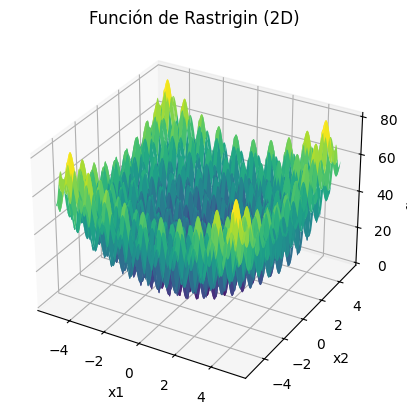

In [8]:
import matplotlib.pyplot as plt
import numpy as np 

# Rango de búsqueda
X = np.linspace(-5.12, 5.12, 200) #Creamos nuestra malla para graficar 
Y = np.linspace(-5.12, 5.12, 200) #Lo mismo para Y
X, Y = np.meshgrid(X, Y)

Z = 10*2 + (X**2 - 10*np.cos(2*np.pi*X)) + (Y**2 - 10*np.cos(2*np.pi*Y)) #Tomamos x y y dado que nuestra funcion es de 2 variables

# Superficie
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_title("Función de Rastrigin (2D)")
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(x1,x2)')
plt.show()


In [9]:
import numpy as np 
def Rastrigin(x): #DEFINIMOS LA FUNCION DE RASTRIGIN
    n = 2
    return 10*n + sum(x**2 - 10 * np.cos(2 * np.pi * x))

def ini_pob(tam_pob, num_ind, Imin, Imax): #INICIALIZAMOS LA POBLACION -- 
    Poblacion = np.random.uniform(Imin, Imax, size=(tam_pob, num_ind)) 
    """#Generamos una matriz de el tamaño de la población y el número de individuos con valores aleatorios entre Imin e Imax
    (100x2)"""
    return Poblacion

def evaluar(Poblacion): #EVALUAMOS LA POBLACIÓN --
  [r, c] = Poblacion.shape
  fitness = np.zeros(r)
  for i in range(r):
     fitness[i] = Rastrigin(Poblacion[i, :]) 
  return fitness

def seleccion(Poblacion, fitness, ps): #FUNCION PARA SELECCIONAR LOS MEJORES INDIVIDUOS
  [r, c] = Poblacion.shape
  indices_ordenados = np.argsort(fitness) #Ordenamos los índices de la población según su fitness (de menor a mayor)
  tamaño_elite = int(r*ps) #Calculamos el tamaño de la población elite
  Poblacion_elite = np.zeros((tamaño_elite, c)) #Creamos una matriz para la población elite inicializada en ceros
  for i in range(tamaño_elite): #Llenamos la población elite con los mejores individuos
    Poblacion_elite[i, :] = Poblacion[indices_ordenados[i], :] #Seleccionamos los mejores individuos según los índices ordenados
    
  return Poblacion_elite

#FUNCION PARA ESTIMAR LOS PARAMETROS DE UNA FDP GAUSSIANA A PARTIR DE LA POBLACION ELITE
def estimacion_de_distribucion(Poblacion_elite):
  dim = Poblacion_elite.shape[1] #obtenemos la dimensión (en este caso 2)
  media = np.zeros(dim) #inicializamos vector de media
  stds = np.zeros(dim) #inicializamos vector de std

  for i in range(dim):
    media[i] = np.mean(Poblacion_elite[:, i]) #calculamos la media por columna
    stds[i] = np.std(Poblacion_elite[:, i]) #calculamos la std por columna

  return media, stds

# FUNCIÓN QUE CALCULA LA MEDIA Y LA STDS
def BUMDA_media_stds(Pob_elite, g, Imin, Imax, beta=1.0):
    [m, d] = Pob_elite.shape

    Z = m / ((Imax - Imin) * np.sum(np.exp(beta * g)))

    mu = np.zeros(d)
    sigma = np.zeros(d)

    for j in range(d):
        xj = Pob_elite[:, j]

        # Media
        mu_term1 = (1 / (Z * beta)) * np.sum(np.exp(beta * g) * xj)
        denom_mu = ((Imax - Imin) * beta) * np.sum(g)
        mu_term2 = np.sum(g * xj) / denom_mu
        mu[j] = mu_term1 + mu_term2

        # Varianza
        var_term1 = (1 / (Z * beta)) * np.sum(np.exp(beta * g) * (xj - mu[j])**2)
        var_term2 = np.sum(g * (xj - mu[j])**2) / np.sum(g)
        varianza = var_term1 + var_term2
        sigma[j] = np.sqrt(varianza)

    return mu, sigma

#FUNCION QUE GENERA NUEVA POBLACION MUESTREANDO DE LA DISTRIBUCION GAUSSIANA
def generar_nueva_poblacion(tam_pob, media, stds):
  dim = len(media)
  nueva_poblacion = np.zeros((tam_pob, dim))
  for i in range(tam_pob):
    for j in range(dim):
      nueva_poblacion[i, j] = np.random.normal(media[j], stds[j])

  return nueva_poblacion

In [10]:
# Parámetros
tam_pob = 10000
Imin, Imax = -5.12, 5.12
ps = 0.2
generaciones = 1000
beta = 1.0
mejor_fitness = float('inf')
mejor_solucion = None
# Justo antes del ciclo for
P = ini_pob(tam_pob, 2, Imin, Imax)
for k in range(generaciones):
    # 1. Evaluar la población actual
    fitness = evaluar(P)
    
    # 2. Guardar la mejor solución 
    actual_mejor_fitness = np.min(fitness)
    if actual_mejor_fitness < mejor_fitness:
        mejor_fitness = actual_mejor_fitness
        # Agarra la mejor solución de la población P actual, que corresponde al fitness
        mejor_solucion = P[np.argmin(fitness)].copy()

    # Selección elite
    P_elite = seleccion(P, fitness, ps)
    fitness_elite = evaluar(P_elite)
    
    #  Transformar fitness a ganancia
    epsilon = 1e-6
    g = np.max(fitness_elite) - fitness_elite + epsilon
    
    # Estimar la distribución
    media, stds = BUMDA_media_stds(P_elite, g, Imin, Imax, beta)
    
    # Generar la NUEVA población para la siguiente iteración
    P = generar_nueva_poblacion(tam_pob, media, stds)
    P = np.clip(P, Imin, Imax)

print(f'El mejor cromosoma es: {mejor_solucion}, con fitness: {mejor_fitness}')

El mejor cromosoma es: [ 0.02827874 -0.0147617 ], con fitness: 0.2014371561366204


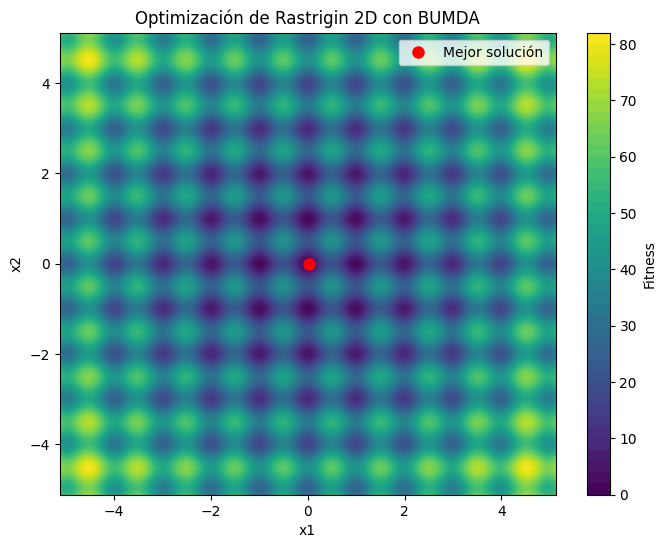

In [11]:
# Mapa de calor de Rastrigin 2D
x = np.linspace(Imin, Imax, 200)
y = np.linspace(Imin, Imax, 200)
X, Y = np.meshgrid(x, y)
Z = 20 + (X**2 - 10*np.cos(2*np.pi*X)) + (Y**2 - 10*np.cos(2*np.pi*Y))

plt.figure(figsize=(8,6))
plt.contourf(X, Y, Z, levels=50, cmap='viridis')
plt.colorbar(label='Fitness')
plt.plot(mejor_solucion[0], mejor_solucion[1], 'ro', markersize=8, label='Mejor solución')
plt.title("Optimización de Rastrigin 2D con BUMDA")
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()
